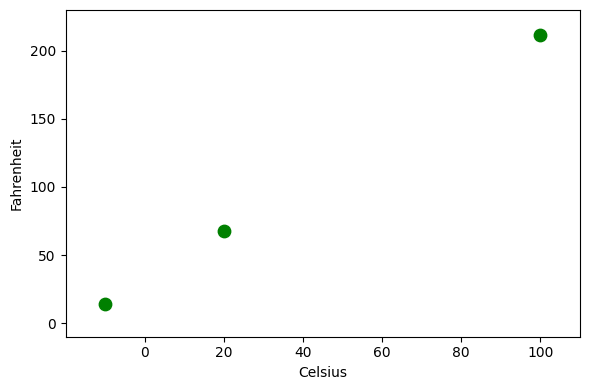

In [1]:
import matplotlib.pyplot as plt

plt.style.use("default")

celsius = [-10, 20, 100]
fahrenheit = [14, 68, 212]

fig, ax = plt.subplots(figsize=(6, 4))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

ax.scatter(celsius, fahrenheit, color="green", s=80)

ax.set_xlabel("Celsius")
ax.set_ylabel("Fahrenheit")
ax.set_xticks([0, 20, 40, 60, 80, 100])
ax.set_yticks([0, 50, 100, 150, 200])
ax.set_xlim(-20, 110)
ax.set_ylim(-10, 230)

plt.tight_layout()
plt.show()



In [2]:
import torch
import torch.nn as nn
import pandas as pd


In [3]:
def convert_celcius_to_farenheit(celcius):
    return (1.8 * celcius + 32)


In [4]:
temp_celcius = [-10, 20, 100]
temp_farenheit = [convert_celcius_to_farenheit(temp) for temp in temp_celcius]


In [5]:
df = pd.DataFrame({"Celcius": temp_celcius, "Farenheit": temp_farenheit})
df


,Celcius,Farenheit
0,-10,14.0
1,20,68.0
2,100,212.0


In [6]:
# Converte os valores da coluna "Celcius" do DataFrame para um vetor float do PyTorch
x = torch.FloatTensor(df.Celcius.values.astype(float))
# Converte os valores da coluna "Farenheit" do DataFrame para um vetor float do PyTorch
y = torch.FloatTensor(df.Farenheit.values.astype(float))
# Adiciona uma dimensão extra à direita de y, transformando-o em um vetor coluna (necessário para a saída do modelo)
y = y.unsqueeze(1)


In [7]:
class Model(nn.Module):  # Define a classe Model herdando de nn.Module (padrão para modelos PyTorch)
    def __init__(self):  # Método construtor da classe Model
        super().__init__()  # Inicializa a superclasse nn.Module
        self.input_layer = nn.Linear(in_features=1, out_features=1, bias=True)  
        # Cria uma camada linear com 1 entrada, 1 saída e viés habilitado

    def forward(self, x):  # Define o método forward (passagem para frente) obrigatório em nn.Module
        out = self.input_layer(x)  # Aplica a camada linear nos dados de entrada x
        return out  # Retorna a saída da camada linear



In [8]:
EPOCHS = 500
LR = 0.2


In [9]:
model = Model()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=LR)


In [10]:
x = x.view(x.size(0), -1)


In [11]:
weights = []
bias = []

for epoch in range(EPOCHS):
    # Calcula as previsões do modelo para os dados de entrada x
    outputs = model.forward(x)
    # Calcula a função de perda (erro quadrático médio entre previsões e valores reais)
    loss = criterion(outputs, y)
    # Zera os gradientes acumulados nos parâmetros antes do backward
    optimizer.zero_grad()
    # Calcula os gradientes da perda em relação aos parâmetros do modelo
    loss.backward()
    # Atualiza os parâmetros do modelo usando o otimizador
    optimizer.step()
    # Salva o valor atual do peso para análise posterior
    weights.append(model.input_layer.weight.item())
    # Salva o valor atual do bias para análise posterior
    bias.append(model.input_layer.bias.item())

print(f"Peso: {model.input_layer.weight.item():.2f} Bias: {model.input_layer.bias.item():.2f}")


Peso: 1.81 Bias: 30.99


In [12]:
training_data = pd.DataFrame({"Pesos": weights, "Bias": bias})
training_data.to_csv("training_data.csv", index=False)


In [13]:
training_data.head(10)

,Pesos,Bias
0,-0.129142,0.740829
1,0.070228,0.940331
2,0.268459,1.138947
3,0.464963,1.336243
4,0.659069,1.531735
5,0.850012,1.724890
6,1.036932,1.915125
7,1.218870,2.101807
8,1.394776,2.284264
9,1.563518,2.461785


In [14]:
valor_para_calcular = 60


In [15]:
print(f"Valor predito: {model.forward(torch.FloatTensor([valor_para_calcular])).item():.2f}")
print(f"Valor real:    {convert_celcius_to_farenheit(valor_para_calcular):.2f}")


Valor predito: 139.63
Valor real:    140.00


In [16]:
import numpy as np
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

step = max(1, len(weights) // 100)
indices = list(range(0, len(weights), step))
if indices[-1] != len(weights) - 1:
    indices.append(len(weights) - 1)

x_line = np.linspace(-20, 110, 200)

fig, ax = plt.subplots(figsize=(6, 4))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

ax.scatter(temp_celcius, temp_farenheit, color="green", s=80, zorder=3, label="Dados")
line, = ax.plot([], [], color="red", lw=2, label="Reta aprendida")
epoch_text = ax.text(0.05, 0.95, "", transform=ax.transAxes, va="top")

ax.set_xlabel("Celsius")
ax.set_ylabel("Fahrenheit")
ax.set_xlim(-20, 110)
ax.set_ylim(-10, 230)
ax.legend(loc="lower right")

def update(frame):
    i = indices[frame]
    w, b = weights[i], bias[i]
    line.set_data(x_line, w * x_line + b)
    epoch_text.set_text(f"Época: {i + 1}/{len(weights)}\nPeso: {w:.2f}  Bias: {b:.2f}")
    return line, epoch_text

ani = FuncAnimation(fig, update, frames=len(indices), interval=50, blit=True)
plt.close(fig)
HTML(ani.to_jshtml())


In [17]:
%pip install -q ipywidgets

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: C:\Users\johna\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
from ipywidgets import interact, FloatSlider
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -50, 50)))

@interact(
    peso=FloatSlider(value=1.0, min=-10.0, max=10.0, step=0.1, description="Peso (w)"),
    bias=FloatSlider(value=0.0, min=-10.0, max=10.0, step=0.1, description="Bias (b)"),
)
def analisar_sigmoide(peso, bias):
    x = np.linspace(-10, 10, 500)
    y = sigmoid(peso * x + bias)
    y_ref = sigmoid(x)  # σ(x) puro, para comparação

    fig, ax = plt.subplots(figsize=(7, 4))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    ax.plot(x, y_ref, color="gray", ls="--", lw=1.5, alpha=0.7, label="σ(x) referência")
    ax.plot(x, y, color="royalblue", lw=2.5, label=f"σ({peso:.1f}x + {bias:.1f})")

    # Fronteira de decisão: wx + b = 0  →  x = -b/w
    if abs(peso) > 1e-6:
        x_decisao = -bias / peso
        if -10 <= x_decisao <= 10:
            ax.axvline(x_decisao, color="tomato", ls=":", lw=1.5, label=f"wx+b=0 em x={x_decisao:.2f}")

    ax.axhline(0.5, color="black", ls="--", lw=0.8, alpha=0.4)
    ax.set_xlim(-10, 10)
    ax.set_ylim(-0.05, 1.05)
    ax.set_xlabel("Entrada x")
    ax.set_ylabel("Saída σ(wx + b)")
    ax.set_title("Sigmoide — efeito do peso e do bias")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()


interactive(children=(FloatSlider(value=1.0, description='Peso (w)', max=10.0, min=-10.0), FloatSlider(value=0…